In [1]:
import torch
import numpy as np
import pandas as pd
import random
import os
import GDCC
from GDCC import Generator, Discriminator

import scanpy as sc
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import warnings
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, jaccard_score, normalized_mutual_info_score, silhouette_score
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 15}) 

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

CURRENT_SEED =10
set_seed(CURRENT_SEED)

latent_dim=32
sub_clusters=2
gp_weight=1
K_param=5 
G_epoch=3
D_epoch=1
num_epochs=600 

expr = pd.read_csv('GSE94820.csv',index_col=0)
celltype = expr.values[:,-2]
batchID = expr.values[:,-1]
df_drop_data = expr.iloc[:,:-2]
Y = pd.factorize(celltype)[0]
unique_class = np.unique(Y)   
X = expr.values[:,:-2].astype('float32')
K = len(np.unique(Y))
ncell,ngene = X.shape[0], X.shape[1] 
print('{} cells, {} genes \nproportion of 0s: {} \n{} different cell types'.format(ncell,ngene,np.mean(X==0),K))
print('{} batches'.format(len(np.unique(batchID))))

drop_data=df_drop_data.values
ncell,ngene = drop_data.shape

'''
norm_data, pca_matrix, leiden_labels, label_leiden_tensor, N_leiden = GDCC.preprocessing(df_drop_data)
kmeans_labels_tensor = GDCC.cluster(pca_matrix, N_leiden,'kmeans')
spectral_labels_tensor = GDCC.cluster(pca_matrix, N_leiden,'spectral')

raw_data, mask_tensor = GDCC.identify_dropout(leiden_labels, norm_data.T, drop_data)
Relation_matrix = GDCC.compute_labels_relation(pca_matrix,leiden_labels,N_leiden,sub_clusters)
CA_tensor=GDCC.A_lap_norm(Relation_matrix,K_param)

G = Generator(ngene , N_leiden, latent_dim, latent_dim)
D = Discriminator(ngene,1024,256,64,16,N_leiden, latent_dim)

label_dim=N_leiden

losses, trained_generator = GDCC.train_DCImpute(G, D,raw_data,CA_tensor,num_epochs, 
                                           label_leiden_tensor, mask_tensor, kmeans_labels_tensor, spectral_labels_tensor,
                                           latent_dim, gp_weight, G_epoch, D_epoch)

imputed_data, generated_data = GDCC.imp_example(label_leiden_tensor, CA_tensor, trained_generator, drop_data, mask_tensor, latent_dim)

df_Imp = pd.DataFrame(imputed_data, index=df_drop_data.index,columns=df_drop_data.columns)
df_Imp.to_csv(f'./GDCC_imputed(GSE94820).csv')
'''

768 cells, 4000 genes 
proportion of 0s: 0.772978515625 
4 different cell types
2 batches


"\nnorm_data, pca_matrix, leiden_labels, label_leiden_tensor, N_leiden = GDCC.preprocessing(df_drop_data)\nkmeans_labels_tensor = GDCC.cluster(pca_matrix, N_leiden,'kmeans')\nspectral_labels_tensor = GDCC.cluster(pca_matrix, N_leiden,'spectral')\n\nraw_data, mask_tensor = GDCC.identify_dropout(leiden_labels, norm_data.T, drop_data)\nRelation_matrix = GDCC.compute_labels_relation(pca_matrix,leiden_labels,N_leiden,sub_clusters)\nCA_tensor=GDCC.A_lap_norm(Relation_matrix,K_param)\n\nG = Generator(ngene , N_leiden, latent_dim, latent_dim)\nD = Discriminator(ngene,1024,256,64,16,N_leiden, latent_dim)\n\nlabel_dim=N_leiden\n\nlosses, trained_generator = GDCC.train_DCImpute(G, D,raw_data,CA_tensor,num_epochs, \n                                           label_leiden_tensor, mask_tensor, kmeans_labels_tensor, spectral_labels_tensor,\n                                           latent_dim, gp_weight, G_epoch, D_epoch)\n\nimputed_data, generated_data = GDCC.imp_example(label_leiden_tensor, CA_ten

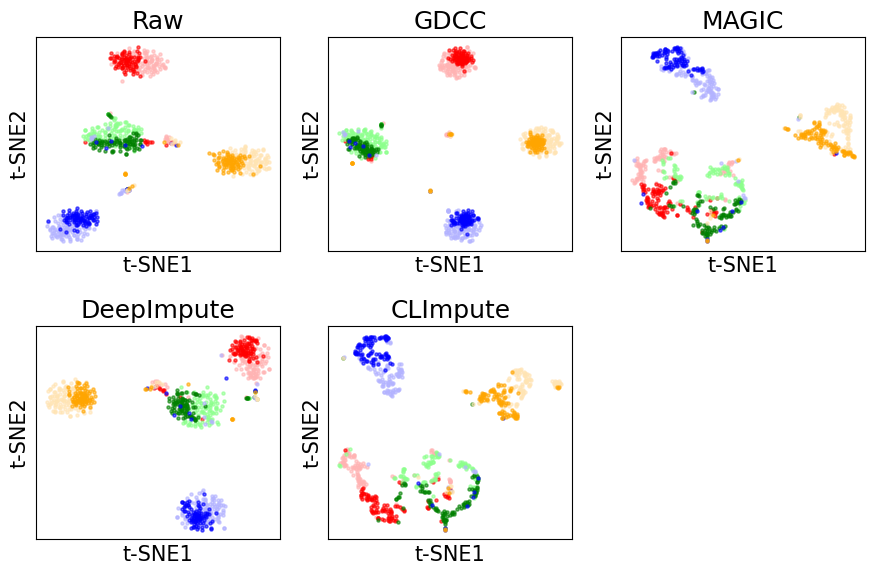

"\nprint('Raw data batch effect metrics:')\nprint(batch_clus(tsne_raw, Y, batchID))\nprint('GDCC imputed data batch effect metrics:')\nprint(batch_clus(tsne_auto, Y, batchID))\nprint('MAGIC imputed data batch effect metrics:')\nprint(batch_clus(tsne_magic, Y, batchID))\nprint('DeepImpute imputed data batch effect metrics:')\nprint(batch_clus(tsne_deep, Y, batchID))\nprint('CLImpute imputed data batch effect metrics:')\nprint(batch_clus(tsne_cl, Y, batchID))\n\nprint('Raw data cell type separation metrics:')\nprint(celltype_clus(tsne_raw, Y))\nprint('GDCC imputed data cell type separation metrics:')\nprint(celltype_clus(tsne_auto, Y))\nprint('MAGIC imputed data cell type separation metrics:')\nprint(celltype_clus(tsne_magic, Y))\nprint('DeepImpute imputed data cell type separation metrics:')\nprint(celltype_clus(tsne_deep, Y))\nprint('CLImpute imputed data cell type separation metrics:')\nprint(celltype_clus(tsne_cl, Y))\n"

In [2]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score,adjusted_rand_score,normalized_mutual_info_score
from sklearn.metrics.cluster import contingency_matrix
from sklearn.preprocessing import StandardScaler
import warnings
from matplotlib.lines import Line2D

import matplotlib.colors as mc
import colorsys

methods = ['GDCC', 'MAGIC', 'DeepImpute', 'CLImpute']

df_Imp = pd.read_csv(f'./GDCC_imputed(GSE94820).csv', index_col=0)
df_MAGIC = pd.read_csv(f'./MAGIC_imputed(GSE94820).csv', index_col=0)
df_Deep = pd.read_csv(f'./DeepImpute_imputed(GSE94820).csv', index_col=0)
df_CL = pd.read_csv(f'./CLImpute_imputed(GSE94820).csv', index_col=0)

def take_norm(data, cellwise_norm=True, log1p=True):
    data_norm = data.copy()
    data_norm = data_norm.astype('float32')
    if cellwise_norm:
        libs = data.sum(axis=1)
        norm_factor = np.diag(np.median(libs) / libs)
        data_norm = np.dot(norm_factor, data_norm)
    if log1p:
        data_norm = np.log2(data_norm + 1.)
    return data_norm

raw_norm_data = take_norm(X)
imp_norm_data = take_norm(df_Imp.values)
magic_norm_data = take_norm(df_MAGIC.values)
deep_norm_data = take_norm(df_Deep.values)
cl_norm_data = take_norm(df_CL.values)

pca_auto = PCA(n_components=50).fit_transform(imp_norm_data)
tsne_auto = TSNE(n_components=2, random_state=1).fit_transform(pca_auto)

pca_magic = PCA(n_components=50).fit_transform(magic_norm_data)
tsne_magic = TSNE(n_components=2, random_state=1).fit_transform(pca_magic)

pca_deep = PCA(n_components=50).fit_transform(deep_norm_data)
tsne_deep = TSNE(n_components=2, random_state=1).fit_transform(pca_deep)

pca_cl = PCA(n_components=50).fit_transform(cl_norm_data)
tsne_cl = TSNE(n_components=2, random_state=1).fit_transform(pca_cl)

pca_raw = PCA(n_components=50).fit_transform(raw_norm_data)
tsne_raw = TSNE(n_components=2, random_state=1).fit_transform(pca_raw)

tsne_list = [tsne_raw, tsne_auto, tsne_magic, tsne_deep, tsne_cl]
title_list = ['Raw', 'GDCC', 'MAGIC', 'DeepImpute', 'CLImpute']

def lighten_color(color, amount=0.5):
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], 1 - amount * (1 - c[1]), c[2])

def purity_score(y_true, y_pred):
    contingency_matrix1 = contingency_matrix(y_true, y_pred)
    return np.sum(np.amax(contingency_matrix1, axis=0)) / np.sum(contingency_matrix1)
 
def batch_clus(tsne, label, batch):
    ncell = len(label)
    Kb = 3
    unique_celltype = np.unique(label)  
    warnings.filterwarnings("ignore")
    df = pd.DataFrame()
    tsnesil, tsneari, tsnenmi, tsneps, tsneji = 0, 0, 0, 0, 0
    for i in unique_celltype:
        kmeans_tsne = KMeans(n_clusters=Kb, random_state=1).fit((tsne[label==i,:]))
        clusterlabel_tsne = kmeans_tsne.labels_
        tsnesil = tsnesil + silhouette_score(StandardScaler().fit_transform(tsne[label==i,:]), batch[label==i]) * np.sum(label==i)
        tsnenmi = tsnenmi + normalized_mutual_info_score(batch[label==i], clusterlabel_tsne) * np.sum(label==i)
        tsneari = tsneari + adjusted_rand_score(batch[label==i], clusterlabel_tsne) * np.sum(label==i)
        tsneps = tsneps + purity_score(batch[label==i], clusterlabel_tsne) * np.sum(label==i)
    df['1-ASW'] = [np.round(1-tsnesil/ncell, 2)]
    df['1-ARI'] = [np.round(1-tsneari/ncell, 2)]
    df['1-NMI'] = [np.round(1-tsnenmi/ncell, 2)]
    df['1-PS'] = [np.round(1-tsneps/ncell, 2)]
    return df

def celltype_clus(tsne, label):
    unique_celltype = np.unique(label)  
    K = len(unique_celltype)
    warnings.filterwarnings("ignore")
    df = pd.DataFrame()
    kmeans = KMeans(n_clusters=K, random_state=1).fit(tsne)
    cluster_label = kmeans.labels_
    df['ASW'] = [np.round(silhouette_score(tsne, label), 2)]
    df['ARI'] = [np.round(adjusted_rand_score(label, cluster_label), 2)]
    df['NMI'] = [np.round(normalized_mutual_info_score(label, cluster_label), 2)]
    df['PS'] = [np.round(purity_score(label, cluster_label), 2)]
    return df

unique_cell_types = np.unique(celltype)

COL = ['red', 'green', 'blue', 'orange']

fig = plt.figure(figsize=(9, 6))

for idx, tsne_data in enumerate(tsne_list):
    ax = fig.add_subplot(2, 3, idx+1)
    for i, ctype in enumerate(unique_cell_types):
        mask = (celltype == ctype)
        ax.scatter(tsne_data[mask & (batchID==1), 0], tsne_data[mask & (batchID==1), 1], s=5, color=lighten_color(COL[i % len(COL)], 0.3), alpha=0.6, label=None)
        ax.scatter(tsne_data[mask & (batchID==2), 0], tsne_data[mask & (batchID==2), 1], s=5, color=lighten_color(COL[i % len(COL)], 1.0), alpha=0.6, label=None)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('t-SNE1')
    ax.set_ylabel('t-SNE2')
    ax.set_title(title_list[idx])

ax_legend = fig.add_subplot(2, 3, 6)
ax_legend.axis('off')

custom_legend_handles = []
custom_legend_labels = []
for i, ctype in enumerate(unique_cell_types):
    color_b1 = lighten_color(COL[i % len(COL)], 0.3)
    color_b2 = lighten_color(COL[i % len(COL)], 1.0)
    
    custom_legend_handles.append(Line2D([0], [0], marker='o', color='w', markerfacecolor='none', markersize=0))
    custom_legend_labels.append(ctype)
    
    custom_legend_handles.append(Line2D([0], [0], marker='o', color='w', markerfacecolor=color_b1, markersize=10))
    custom_legend_labels.append('Batch 1')
    
    custom_legend_handles.append(Line2D([0], [0], marker='o', color='w', markerfacecolor=color_b2, markersize=10))
    custom_legend_labels.append('Batch 2')

fig_legend = plt.figure(figsize=(10, 2))
ax_legend = fig_legend.add_axes([0, 0, 1, 1])
ax_legend.axis('off')

ax_legend.legend(custom_legend_handles, custom_legend_labels, 
           loc='center', 
           frameon=False,
           ncol=len(unique_cell_types),
           columnspacing=1.5, 
           handletextpad=0.5)

fig_legend.savefig('GSE94820_legend.png', dpi=600, bbox_inches='tight')
plt.close(fig_legend)

plt.tight_layout(rect=[0, 0, 1, 1])
plt.savefig('GSE94820_batch_comparison.png', dpi=600)
plt.show()

'''
print('Raw data batch effect metrics:')
print(batch_clus(tsne_raw, Y, batchID))
print('GDCC imputed data batch effect metrics:')
print(batch_clus(tsne_auto, Y, batchID))
print('MAGIC imputed data batch effect metrics:')
print(batch_clus(tsne_magic, Y, batchID))
print('DeepImpute imputed data batch effect metrics:')
print(batch_clus(tsne_deep, Y, batchID))
print('CLImpute imputed data batch effect metrics:')
print(batch_clus(tsne_cl, Y, batchID))

print('Raw data cell type separation metrics:')
print(celltype_clus(tsne_raw, Y))
print('GDCC imputed data cell type separation metrics:')
print(celltype_clus(tsne_auto, Y))
print('MAGIC imputed data cell type separation metrics:')
print(celltype_clus(tsne_magic, Y))
print('DeepImpute imputed data cell type separation metrics:')
print(celltype_clus(tsne_deep, Y))
print('CLImpute imputed data cell type separation metrics:')
print(celltype_clus(tsne_cl, Y))
'''

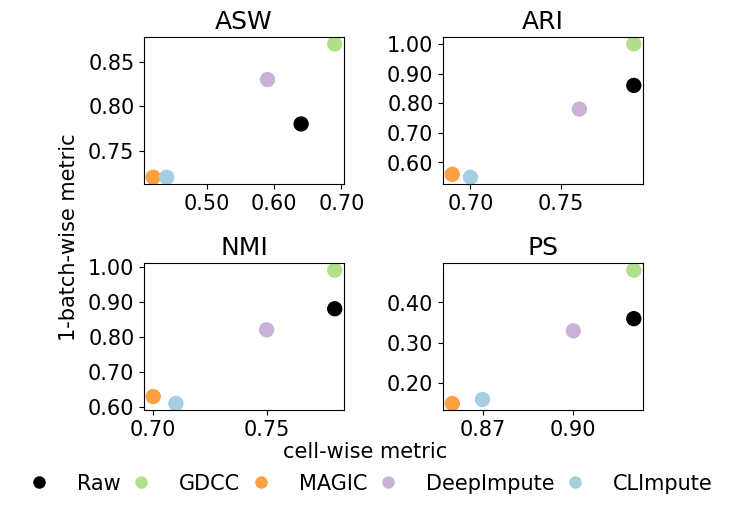

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator, FuncFormatter

raw_batch = np.array([0.78, 0.86, 0.88, 0.36])
gdcc_batch = np.array([0.87, 1.0, 0.99, 0.48])
magic_batch = np.array([0.72, 0.56, 0.63, 0.15])
deep_batch = np.array([0.83, 0.78, 0.82, 0.33])
cl_batch = np.array([0.72, 0.55, 0.61, 0.16])

raw_cell = np.array([0.64, 0.79, 0.78, 0.92])
gdcc_cell = np.array([0.69, 0.79, 0.78, 0.92])
magic_cell = np.array([0.42, 0.69, 0.7, 0.86])
deep_cell = np.array([0.59, 0.76, 0.75, 0.9])
cl_cell = np.array([0.44, 0.7, 0.71, 0.87])

cell_wise_asw = [raw_cell[0], gdcc_cell[0], magic_cell[0], deep_cell[0], cl_cell[0]]
cell_wise_ari = [raw_cell[1], gdcc_cell[1], magic_cell[1], deep_cell[1], cl_cell[1]]
cell_wise_nmi = [raw_cell[2], gdcc_cell[2], magic_cell[2], deep_cell[2], cl_cell[2]]
cell_wise_ps = [raw_cell[3], gdcc_cell[3], magic_cell[3], deep_cell[3], cl_cell[3]]

batch_wise_asw = [raw_batch[0], gdcc_batch[0], magic_batch[0], deep_batch[0], cl_batch[0]]
batch_wise_ari = [raw_batch[1], gdcc_batch[1], magic_batch[1], deep_batch[1], cl_batch[1]]
batch_wise_nmi = [raw_batch[2], gdcc_batch[2], magic_batch[2], deep_batch[2], cl_batch[2]]
batch_wise_ps = [raw_batch[3], gdcc_batch[3], magic_batch[3], deep_batch[3], cl_batch[3]]

colors = ['black', '#B2E08A', '#FEA042', '#CBB1D5', '#A6CEE3']

fig, axs = plt.subplots(2, 2, figsize=(6, 5))
s = 100 

axs[0, 0].scatter(cell_wise_asw, batch_wise_asw, c=colors, marker='o', s=s)
axs[0, 0].set_title('ASW')

axs[0, 1].scatter(cell_wise_ari, batch_wise_ari, c=colors, marker='o', s=s)
axs[0, 1].set_title('ARI')

axs[1, 0].scatter(cell_wise_nmi, batch_wise_nmi, c=colors, marker='o', s=s)
axs[1, 0].set_title('NMI')

axs[1, 1].scatter(cell_wise_ps, batch_wise_ps, c=colors, marker='o', s=s)
axs[1, 1].set_title('PS')

def one_decimal_formatter(x, pos):
    return f'{x:.2f}'
    
x_tick_intervals = [0.1, 0.05, 0.05, 0.03]
y_tick_intervals = [0.05, 0.1, 0.1, 0.1]

for i, ax in enumerate(axs.flat):
    ax.xaxis.set_major_locator(MultipleLocator(x_tick_intervals[i]))
    ax.yaxis.set_major_locator(MultipleLocator(y_tick_intervals[i]))
    
    ax.xaxis.set_major_formatter(FuncFormatter(one_decimal_formatter))
    ax.yaxis.set_major_formatter(FuncFormatter(one_decimal_formatter))
    
fig.text(0.5, 0.05, 'cell-wise metric', ha='center', va='bottom')
fig.text(-0.01, 0.5, '1-batch-wise metric', ha='left', va='center', rotation=90)

legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='Raw', markerfacecolor='black', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='GDCC', markerfacecolor='#B2E08A', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='MAGIC', markerfacecolor='#FEA042', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='DeepImpute', markerfacecolor='#CBB1D5', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='CLImpute', markerfacecolor='#A6CEE3', markersize=10)
]

fig.legend(handles=legend_elements, loc='lower center', ncol=5, frameon=False, bbox_to_anchor=(0.5, -0.05), columnspacing=0.01)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('evaluation_metrics_GSE94820.png', dpi=600)
plt.show()